<a href="https://colab.research.google.com/github/dang710206/Baitap-AI-/blob/main/Bt6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 4.8 MB/s eta 0:00:00


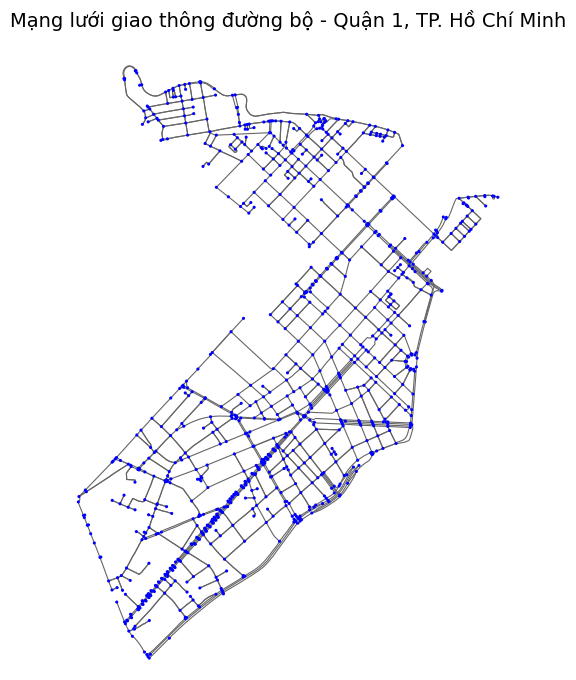

 Đã vẽ bản đồ mạng lưới giao thông.

 PHÂN TÍCH CƠ BẢN MẠNG LƯỚI GIAO THÔNG:
   Số nút (nodes): 989
   Số cạnh (edges): 2,090
   Số nút giao thông: 874
   Chiều dài đường trung bình: 81.3 mét
   Tổng chiều dài đường: 118.3 km
   Diện tích khu vực: 7.70 km²
   Mật độ nút giao: 114 nút/km²

 Vai trò của dữ liệu mạng giao thông OSMnx trong hệ thống AI đô thị thông minh:
- Xây dựng mô hình tìm đường ngắn nhất (shortest path) cho ứng dụng bản đồ, gọi xe.
- Phân tích ùn tắc giao thông, dự báo lưu lượng xe.
- Tối ưu hóa vị trí trạm xe buýt, điểm dừng, kho hàng.
- Hỗ trợ lập kế hoạch hạ tầng giao thông thông minh.
- Kết hợp với dữ liệu thời gian thực để điều hướng động (dynamic routing).


In [6]:
import osmnx as ox
import matplotlib.pyplot as plt

# Cài đặt hiển thị log để theo dõi quá trình
ox.settings.log_console = True

# Khai báo khu vực nghiên cứu (có thể thay đổi thành khu vực khác nếu cần)
place = "District 1, Ho Chi Minh City, Vietnam"

# Tải graph mạng lưới giao thông đường bộ
G = ox.graph_from_place(place, network_type='drive', simplify=True)


fig, ax = ox.plot_graph(
    G,
    node_color='blue',
    node_size=5,
    edge_color='#666666',
    edge_linewidth=0.8,
    bgcolor='white',
    show=False,
    close=False
)

# Thêm tiêu đề cho bản đồ
ax.set_title("Mạng lưới giao thông đường bộ - Quận 1, TP. Hồ Chí Minh", fontsize=14, pad=20)

plt.show()

print(" Đã vẽ bản đồ mạng lưới giao thông.")

# Tính các chỉ số cơ bản
stats = ox.basic_stats(G)

# Một số chỉ số quan trọng
so_nut = stats['n']                    # số nút (nodes)
so_canh = stats['m']                   # số cạnh (edges)
so_nut_giao = stats.get('intersection_count', stats['n'])  # số nút giao
chieu_dai_duong_tb = stats.get('street_length_avg', 0)
chieu_dai_duong_tong = stats.get('street_length_total', 0)

# Tính diện tích khu vực (đơn vị km²)
gdf_area = ox.geocode_to_gdf(place)
area_sqm = gdf_area.to_crs('+proj=cea').area.iloc[0]
area_km2 = area_sqm / 1_000_000

# Mật độ nút giao
mat_do_nut_giao = so_nut_giao / area_km2 if area_km2 > 0 else 0


# In kết quả phân tích
print("\n PHÂN TÍCH CƠ BẢN MẠNG LƯỚI GIAO THÔNG:")
print(f"   Số nút (nodes): {so_nut:,}")
print(f"   Số cạnh (edges): {so_canh:,}")
print(f"   Số nút giao thông: {so_nut_giao:,}")
print(f"   Chiều dài đường trung bình: {chieu_dai_duong_tb:.1f} mét")
print(f"   Tổng chiều dài đường: {chieu_dai_duong_tong/1000:.1f} km")
print(f"   Diện tích khu vực: {area_km2:.2f} km²")
print(f"   Mật độ nút giao: {mat_do_nut_giao:.0f} nút/km²")

print("\n Vai trò của dữ liệu mạng giao thông OSMnx trong hệ thống AI đô thị thông minh:")
print("- Xây dựng mô hình tìm đường ngắn nhất (shortest path) cho ứng dụng bản đồ, gọi xe.")
print("- Phân tích ùn tắc giao thông, dự báo lưu lượng xe.")
print("- Tối ưu hóa vị trí trạm xe buýt, điểm dừng, kho hàng.")
print("- Hỗ trợ lập kế hoạch hạ tầng giao thông thông minh.")
print("- Kết hợp với dữ liệu thời gian thực để điều hướng động (dynamic routing).")